In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load the Dataset :

In [2]:
test_df=pd.read_csv("test.csv")

In [3]:
train_df=pd.read_csv("train.csv")

In [4]:
test_df.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [5]:
train_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [6]:
test_df.shape,train_df.shape

((153164, 2), (159571, 8))

In [7]:
test_df.columns,train_df.columns

(Index(['id', 'comment_text'], dtype='object'),
 Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
        'insult', 'identity_hate'],
       dtype='object'))

In [8]:
test_df.info()
print("_________________________________________")
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153164 entries, 0 to 153163
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            153164 non-null  object
 1   comment_text  153164 non-null  object
dtypes: object(2)
memory usage: 2.3+ MB
_________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [9]:
test_df.dtypes
# print("_________________________________________")
#train_df.dtypes

id              object
comment_text    object
dtype: object

In [10]:
import missingno as mn

<Axes: >

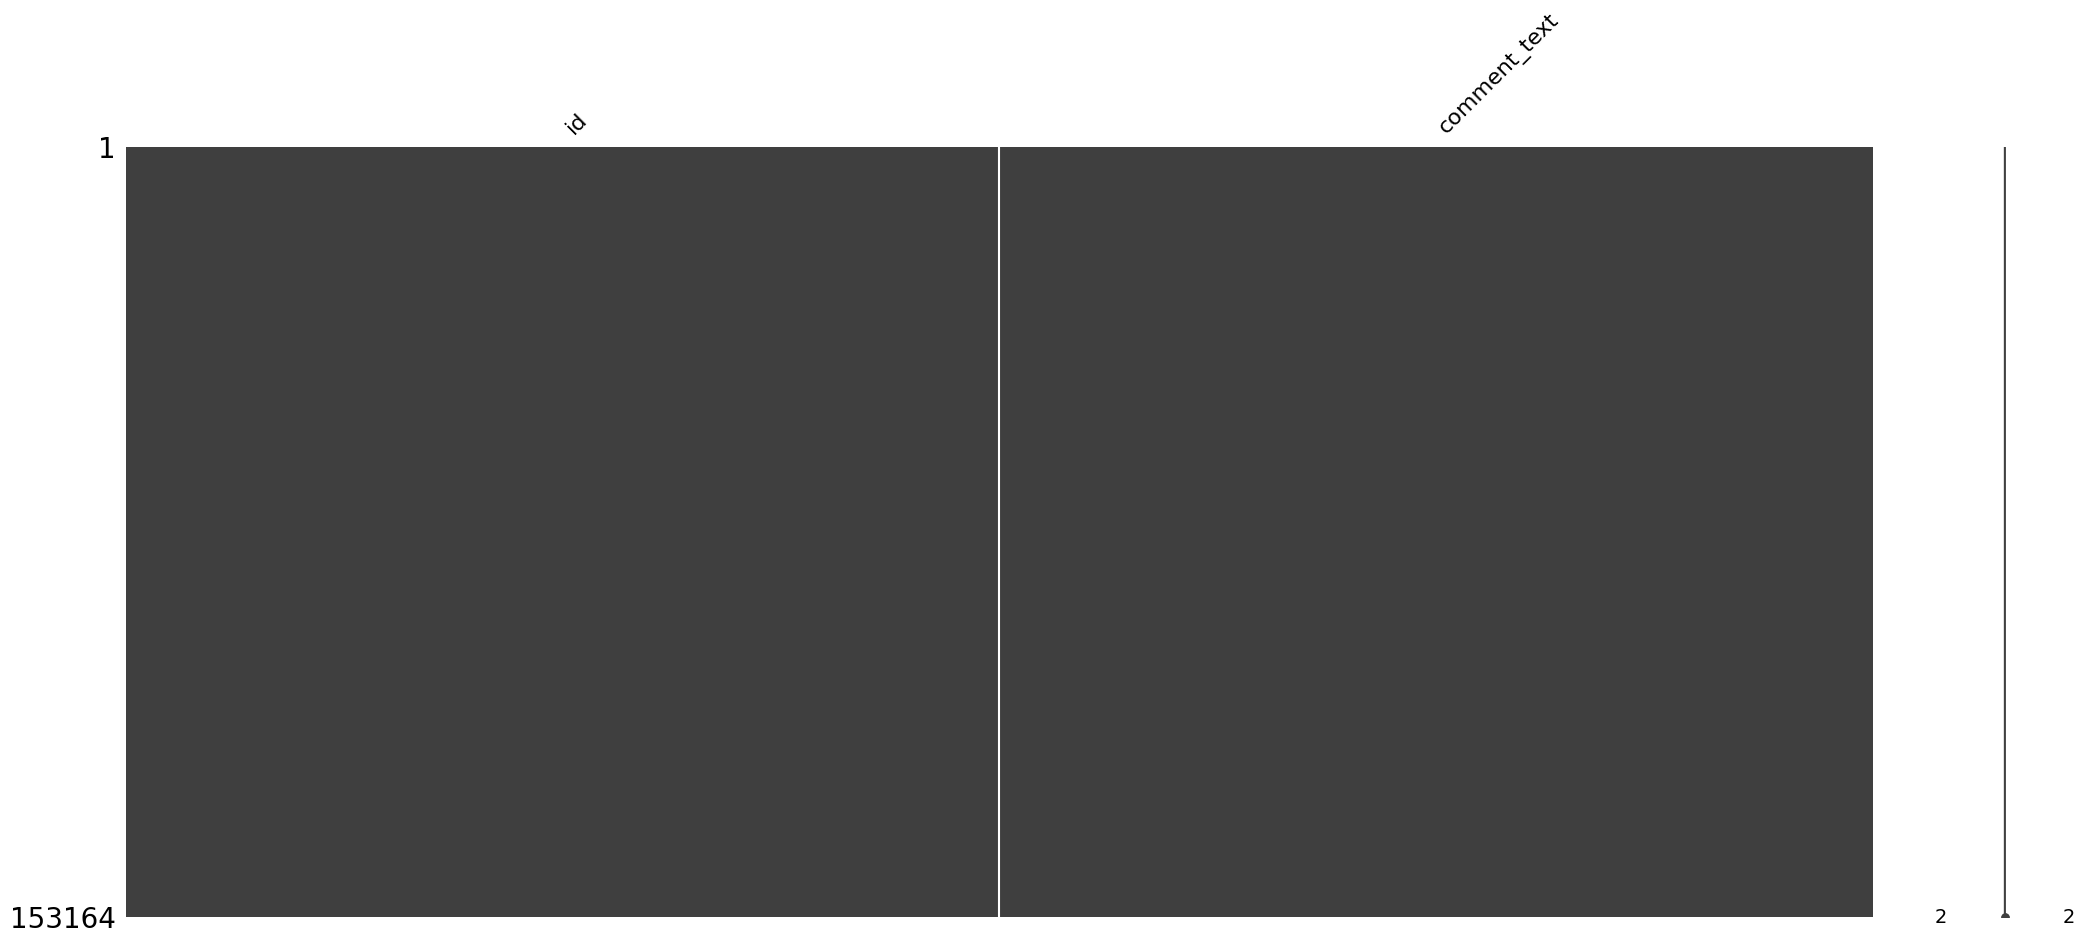

In [11]:
mn.matrix(test_df)

<Axes: >

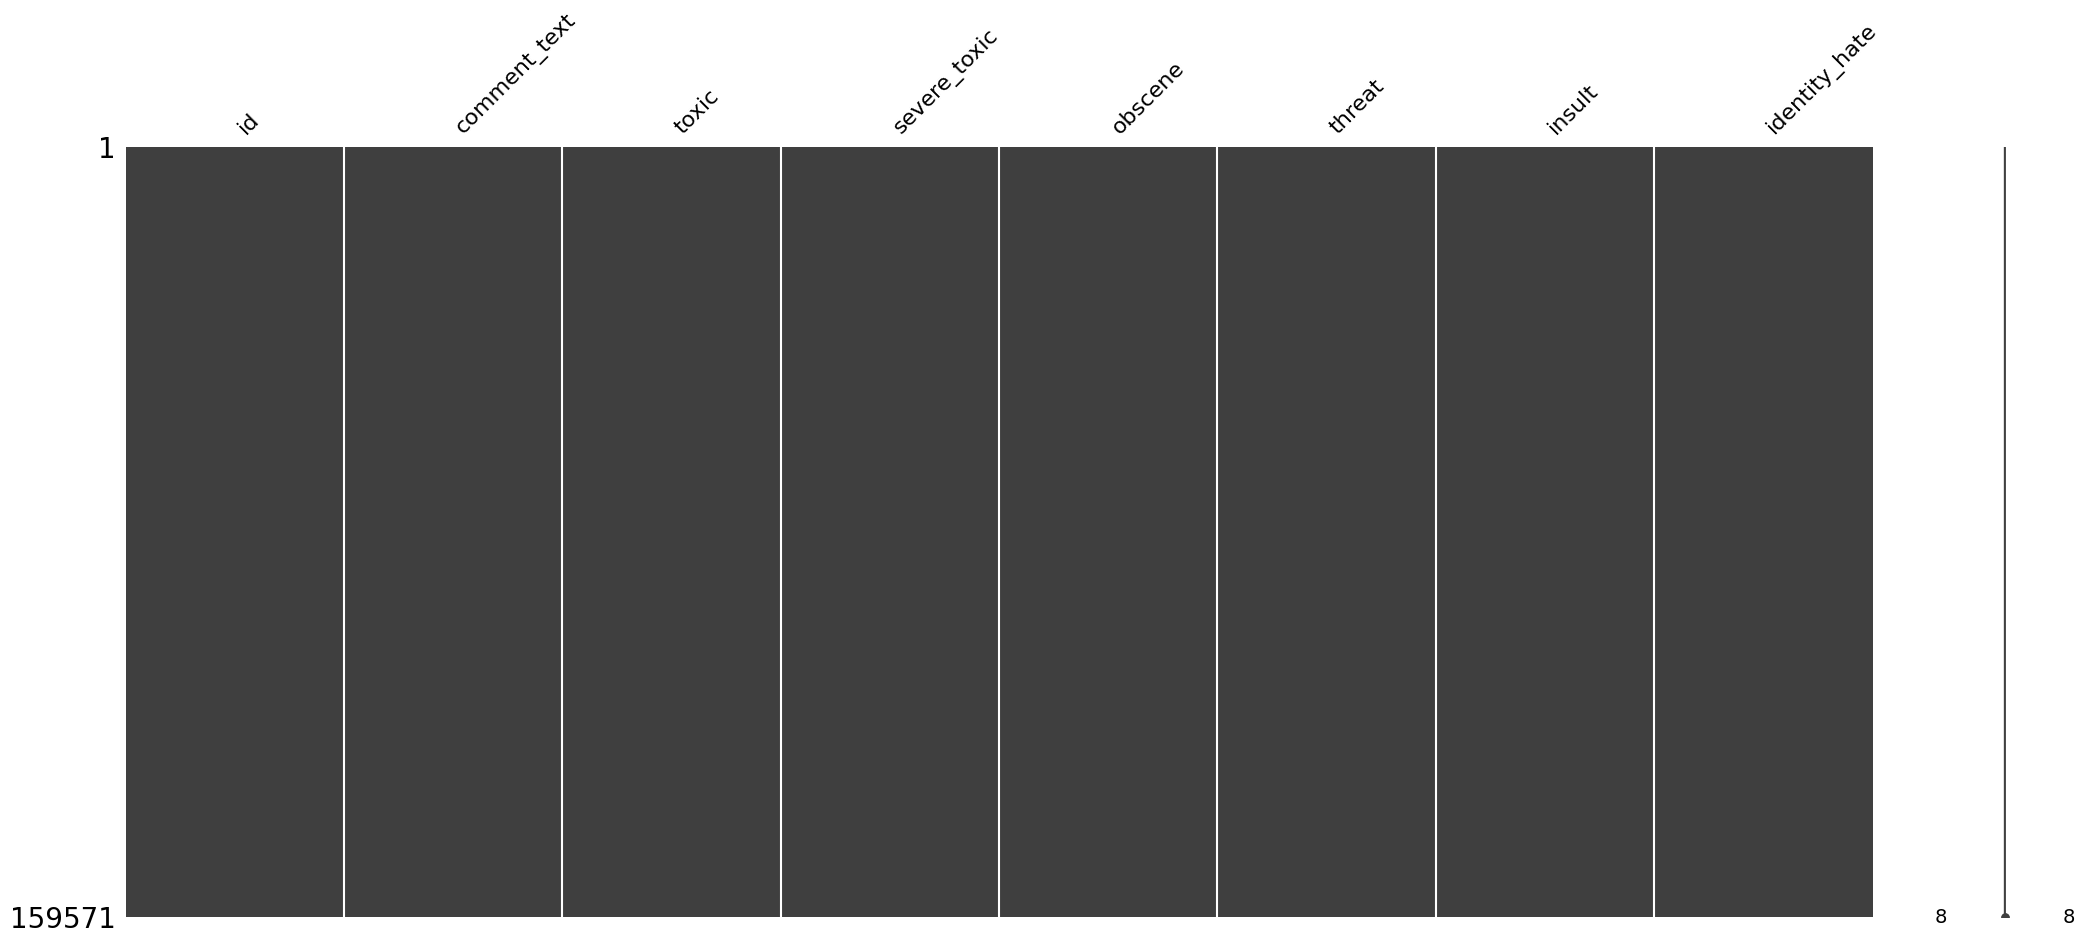

In [12]:
mn.matrix(train_df)

In [13]:
test_df.duplicated().sum()

np.int64(0)

In [14]:
train_df.duplicated().sum()

np.int64(0)

In [15]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [16]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153164 entries, 0 to 153163
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            153164 non-null  object
 1   comment_text  153164 non-null  object
dtypes: object(2)
memory usage: 2.3+ MB


### Text Cleaning

In [18]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text

train_df['clean_text'] = train_df['comment_text'].apply(clean_text)
test_df['clean_text'] = test_df['comment_text'].apply(clean_text)


### Tokenization

In [19]:
def tokenize(text):
    return text.split()

train_df['tokens'] = train_df['clean_text'].apply(tokenize)
test_df['tokens'] = test_df['clean_text'].apply(tokenize)


In [20]:
train_df[['clean_text','tokens']].head()


,clean_text,tokens
0,explanation why the edits made under my userna...,"[explanation, why, the, edits, made, under, my..."
1,d aww he matches this background colour i m s...,"[d, aww, he, matches, this, background, colour..."
2,hey man i m really not trying to edit war it...,"[hey, man, i, m, really, not, trying, to, edit..."
3,more i can t make any real suggestions on im...,"[more, i, can, t, make, any, real, suggestions..."
4,you sir are my hero any chance you remember...,"[you, sir, are, my, hero, any, chance, you, re..."


### Import NLP libraries

In [22]:
!pip install nltk

### Stopword Removal

In [23]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

train_df['no_stopwords'] = train_df['tokens'].apply(remove_stopwords)
test_df['no_stopwords'] = test_df['tokens'].apply(remove_stopwords)


[nltk_data] Downloading package stopwords to C:\Users\YAZHINI.YAZHNI-
[nltk_data]     EM-SYS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Lemmatization

In [24]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_words(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

train_df['lemmatized'] = train_df['no_stopwords'].apply(lemmatize_words)
test_df['lemmatized'] = test_df['no_stopwords'].apply(lemmatize_words)


[nltk_data] Downloading package wordnet to C:\Users\YAZHINI.YAZHNI-EM-
[nltk_data]     SYS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Join Back to Text

In [25]:
def join_text(tokens):
    return " ".join(tokens)

train_df['final_text'] = train_df['lemmatized'].apply(join_text)
test_df['final_text'] = test_df['lemmatized'].apply(join_text)


In [26]:
train_df[['comment_text','final_text']].head()


,comment_text,final_text
0,Explanation\nWhy the edits made under my usern...,explanation edits made username hardcore metal...
1,D'aww! He matches this background colour I'm s...,aww match background colour seemingly stuck th...
2,"Hey man, I'm really not trying to edit war. It...",hey man really trying edit war guy constantly ...
3,"""\nMore\nI can't make any real suggestions on ...",make real suggestion improvement wondered sect...
4,"You, sir, are my hero. Any chance you remember...",sir hero chance remember page


### Vectorization

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(train_df['final_text'])
y = train_df['toxic']


### Train-Test Split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Train Baseline Model

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Make Predictions

In [31]:
y_pred = model.predict(X_val)


### Evaluate Model

In [32]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_val, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_val, y_pred))


Accuracy: 0.9586088046373179
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     28859
           1       0.91      0.63      0.75      3056

    accuracy                           0.96     31915
   macro avg       0.93      0.81      0.86     31915
weighted avg       0.96      0.96      0.96     31915



In [33]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train, y_train)


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


### Save Model & Vectorizer

In [34]:
import pickle

pickle.dump(model, open("toxic_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))
